In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [ ]:
#1. import database /data

In [5]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect('customer_churn.db')

# Get all table names
sql_query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(sql_query, conn)

# Create a DataFrame for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created DataFrame: df_{table_name}")

# Close the connection after reading all tables
conn.close()


Created DataFrame: df_db_customer
Created DataFrame: df_db_subscription
Created DataFrame: df_db_support


In [ ]:
# data cleaning 

In [14]:
df_db_customer.head()


,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [7]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [ ]:
# a rename name coL - name

In [13]:
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)


In [40]:
#df_db_customer.drop(df_db_customer.columns[-2:], axis = 1)
pd.to_datetime(df_db_customer['dob'])

KeyError: 'dob'

In [39]:
df_db_customer.tail()

,customerid,customer_name,country,state
16,0020-JDNXP,rikim,India,Meghalaya
17,0021-IKXGC,vishakha,India,Rajasthan
18,0022-TCJCI,raghvendra,India,Telangana
19,0023-HGHWL,rishabh,India,Uttar Pradesh
20,0023-UYUPN,sudevi,India,Maharashtra


KeyError: "['interest'] not found in axis"

KeyError: "['interest', 'pincode'] not found in axis"

,customerid,customer_name,country,state
0,0002-ORFBO,keshav,India,Maharashtra
1,0003-MKNFE,raghav,India,Karnataka
2,0004-TLHLJ,lalita,India,Delhi
3,0011-IGKFF,mohan,India,Nagaland
4,0013-EXCHZ,mira,India,Delhi


,customerid,customer_name,country,state
16,0020-JDNXP,rikim,India,Meghalaya
17,0021-IKXGC,vishakha,India,Rajasthan
18,0022-TCJCI,raghvendra,India,Telangana
19,0023-HGHWL,rishabh,India,Uttar Pradesh
20,0023-UYUPN,sudevi,India,Maharashtra


KeyError: 'dob'

In [31]:
z

KeyError: 'dob'

,customerid,customer_name
0,0002-ORFBO,keshav
1,0003-MKNFE,raghav
2,0004-TLHLJ,lalita
3,0011-IGKFF,mohan
4,0013-EXCHZ,mira
5,0013-MHZWF,durga
6,0013-SMEOE,mina
7,0014-BMAQU,madan
8,0015-UOCOJ,maya
9,0016-QLJIS,arjun


,customerid,customer_name
0,0002-ORFBO,keshav
1,0003-MKNFE,raghav
2,0004-TLHLJ,lalita
3,0011-IGKFF,mohan
4,0013-EXCHZ,mira
5,0013-MHZWF,durga
6,0013-SMEOE,mina
7,0014-BMAQU,madan
8,0015-UOCOJ,maya
9,0016-QLJIS,arjun


TypeError: flex_arith_method_FRAME.<locals>.f() got an unexpected keyword argument 'columns'

In [38]:
df_db_customer.head()

,customerid,customer_name,country,state
0,0002-ORFBO,keshav,India,Maharashtra
1,0003-MKNFE,raghav,India,Karnataka
2,0004-TLHLJ,lalita,India,Delhi
3,0011-IGKFF,mohan,India,Nagaland
4,0013-EXCHZ,mira,India,Delhi


In [41]:
df_db_customer.tail()

,customerid,customer_name,country,state
16,0020-JDNXP,rikim,India,Meghalaya
17,0021-IKXGC,vishakha,India,Rajasthan
18,0022-TCJCI,raghvendra,India,Telangana
19,0023-HGHWL,rishabh,India,Uttar Pradesh
20,0023-UYUPN,sudevi,India,Maharashtra


In [42]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
dtypes: object(4)
memory usage: 804.0+ bytes


In [44]:
import sqlite3

conn = sqlite3.connect('customer_churn.db')
cursor = conn.cursor()

cursor.execute("ALTER TABLE df_db_customer ADD COLUMN gender TEXT;")
cursor.execute("ALTER TABLE df_db_customer ADD COLUMN dob TEXT;")

conn.commit()
conn.close()

OperationalError: no such table: df_db_customer

In [45]:
df_db_customer['gender'] = None

In [46]:
import pandas as pd

df_db_customer['dob'] = pd.NaT

In [47]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,None,NaT
1,0003-MKNFE,raghav,India,Karnataka,None,NaT
2,0004-TLHLJ,lalita,India,Delhi,None,NaT
3,0011-IGKFF,mohan,India,Nagaland,None,NaT
4,0013-EXCHZ,mira,India,Delhi,None,NaT


In [48]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         0 non-null      object        
 5   dob            0 non-null      datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [49]:
df_db_customer.drop(df_db_customer.columns[-2:], axis = 1)

,customerid,customer_name,country,state
0,0002-ORFBO,keshav,India,Maharashtra
1,0003-MKNFE,raghav,India,Karnataka
2,0004-TLHLJ,lalita,India,Delhi
3,0011-IGKFF,mohan,India,Nagaland
4,0013-EXCHZ,mira,India,Delhi
5,0013-MHZWF,durga,None,Delhi
6,0013-SMEOE,mina,India,Meghalaya
7,0014-BMAQU,madan,India,Rajasthan
8,0015-UOCOJ,maya,None,Kathmandu
9,0016-QLJIS,arjun,Nepal,Kathmandu


In [50]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("customer_churn.db")

df_original = pd.read_sql(
    "SELECT customerid, gender, dob FROM db_customer",
    conn
)

conn.close()

df_db_customer = df_db_customer.merge(
    df_original,
    on="customerid",
    how="left"
)

In [51]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender_x       0 non-null      object        
 5   dob_x          0 non-null      datetime64[ns]
 6   gender_y       21 non-null     object        
 7   dob_y          21 non-null     object        
dtypes: datetime64[ns](1), object(7)
memory usage: 1.5+ KB


In [52]:
df_db_customer.head()

,customerid,customer_name,country,state,gender_x,dob_x,gender_y,dob_y
0,0002-ORFBO,keshav,India,Maharashtra,None,NaT,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,None,NaT,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,None,NaT,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,None,NaT,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,None,NaT,Female,1990-05-05 00:00:00


In [53]:
df_db_customer.drop(df_db_customer.columns[-2:], axis = 1)

,customerid,customer_name,country,state,gender_x,dob_x
0,0002-ORFBO,keshav,India,Maharashtra,None,NaT
1,0003-MKNFE,raghav,India,Karnataka,None,NaT
2,0004-TLHLJ,lalita,India,Delhi,None,NaT
3,0011-IGKFF,mohan,India,Nagaland,None,NaT
4,0013-EXCHZ,mira,India,Delhi,None,NaT
5,0013-MHZWF,durga,None,Delhi,None,NaT
6,0013-SMEOE,mina,India,Meghalaya,None,NaT
7,0014-BMAQU,madan,India,Rajasthan,None,NaT
8,0015-UOCOJ,maya,None,Kathmandu,None,NaT
9,0016-QLJIS,arjun,Nepal,Kathmandu,None,NaT


In [54]:
df_db_customer.drop(df_db_customer.columns[-2:], axis = 1)

,customerid,customer_name,country,state,gender_x,dob_x
0,0002-ORFBO,keshav,India,Maharashtra,None,NaT
1,0003-MKNFE,raghav,India,Karnataka,None,NaT
2,0004-TLHLJ,lalita,India,Delhi,None,NaT
3,0011-IGKFF,mohan,India,Nagaland,None,NaT
4,0013-EXCHZ,mira,India,Delhi,None,NaT
5,0013-MHZWF,durga,None,Delhi,None,NaT
6,0013-SMEOE,mina,India,Meghalaya,None,NaT
7,0014-BMAQU,madan,India,Rajasthan,None,NaT
8,0015-UOCOJ,maya,None,Kathmandu,None,NaT
9,0016-QLJIS,arjun,Nepal,Kathmandu,None,NaT


In [55]:
df_db_customer.drop(df_db_customer.columns[-2:], axis = 1)

,customerid,customer_name,country,state,gender_x,dob_x
0,0002-ORFBO,keshav,India,Maharashtra,None,NaT
1,0003-MKNFE,raghav,India,Karnataka,None,NaT
2,0004-TLHLJ,lalita,India,Delhi,None,NaT
3,0011-IGKFF,mohan,India,Nagaland,None,NaT
4,0013-EXCHZ,mira,India,Delhi,None,NaT
5,0013-MHZWF,durga,None,Delhi,None,NaT
6,0013-SMEOE,mina,India,Meghalaya,None,NaT
7,0014-BMAQU,madan,India,Rajasthan,None,NaT
8,0015-UOCOJ,maya,None,Kathmandu,None,NaT
9,0016-QLJIS,arjun,Nepal,Kathmandu,None,NaT


In [56]:
df_db_customer.drop(df_db_customer.columns[-2:], axis = 1)

,customerid,customer_name,country,state,gender_x,dob_x
0,0002-ORFBO,keshav,India,Maharashtra,None,NaT
1,0003-MKNFE,raghav,India,Karnataka,None,NaT
2,0004-TLHLJ,lalita,India,Delhi,None,NaT
3,0011-IGKFF,mohan,India,Nagaland,None,NaT
4,0013-EXCHZ,mira,India,Delhi,None,NaT
5,0013-MHZWF,durga,None,Delhi,None,NaT
6,0013-SMEOE,mina,India,Meghalaya,None,NaT
7,0014-BMAQU,madan,India,Rajasthan,None,NaT
8,0015-UOCOJ,maya,None,Kathmandu,None,NaT
9,0016-QLJIS,arjun,Nepal,Kathmandu,None,NaT


In [57]:
df_db_customer.drop(columns=['gender', 'dob'], inplace=True)

KeyError: "['gender', 'dob'] not found in axis"

In [58]:
df_db_customer.drop(columns=['gender_x', 'dob_x'], inplace=True)

In [59]:
df_db_customer.infi()

AttributeError: 'DataFrame' object has no attribute 'infi'

In [60]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender_y       21 non-null     object
 5   dob_y          21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [61]:
df_db_customer.head()

,customerid,customer_name,country,state,gender_y,dob_y
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00


In [62]:
df_db_customer.rename(columns = {'gender_y' : 'gender'}, inplace= True)

In [63]:
df_db_customer.rename(columns = {'dob_y' : 'dob'}, inplace= True)

In [67]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [66]:
pd.to_datetime(df_db_customer['dob'],implace = True)

TypeError: to_datetime() got an unexpected keyword argument 'implace'

In [68]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [69]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [70]:
df_db_customer['gender'].replace({'Men': 'Male','Women':'Female'})

0       Male
1       Male
2     Female
3       Male
4     Female
5     Female
6     Female
7       Male
8     Female
9       Male
10      Male
11    Female
12    Female
13    Female
14      Male
15    Female
16    Female
17    Female
18      Male
19      Male
20    Female
Name: gender, dtype: object

In [71]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [72]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [75]:
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [76]:
df_db_customer[df_db_customer['country'].isna()]


,customerid,customer_name,country,state,gender,dob


In [77]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [78]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [80]:
date_col = [' subscription_start_date ', 'renewal_date ',' cancellation_date']
df_db_subscription[date_col].apply(pd.to_datetime)

KeyError: "None of [Index([' subscription_start_date ', 'renewal_date ', ' cancellation_date'], dtype='object')] are in the [columns]"

In [81]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [82]:
date_col = [' subscription_start_date ', 'renewal_date ',' cancellation_date']
df_db_subscription[date_col].apply(pd.to_datetime)

KeyError: "None of [Index([' subscription_start_date ', 'renewal_date ', ' cancellation_date'], dtype='object')] are in the [columns]"

In [83]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [84]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [85]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [86]:
 df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [87]:
 df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [89]:
df_db_support.drop(columns=['col_1', 'comment'], implace = True)

TypeError: DataFrame.drop() got an unexpected keyword argument 'implace'

In [90]:
df_db_support.drop(columns=['col_1','comment'], implace = True)

TypeError: DataFrame.drop() got an unexpected keyword argument 'implace'

In [91]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [92]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [93]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [94]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [ ]:
#feature engineering and data anaylsis

In [95]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [96]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [99]:
df = (df_db_subscription
.merge(df_db_customer, on ='customerid',how='left')
.merge(df_db_support, on ='customerid',how='left') )

In [100]:
df.shape()

TypeError: 'tuple' object is not callable

In [101]:
df.shape

(23, 20)

In [102]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [103]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [105]:
df_db_support.sort_values('complaint_date'),drop_duplicates=('customerid', keep ='last')

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (3553929913.py, line 1)

In [106]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates(subset='customerid', keep='last')

In [107]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [108]:
df = (df_db_subscription
.merge(df_db_customer, on ='customerid',how='left')
.merge(df_db_support, on ='customerid',how='left') )

In [109]:
df.shape

(21, 21)

In [110]:
df.to_csv('exported_churn_data.csv', index = False)

In [ ]:
#data analysis 

In [ ]:
#1 churn rate


In [112]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate =", round(churn_rate,2),"%")

Churn Rate = 28.57 %


In [113]:
retention_rate = 100-churn_rate
print("Retention Rate =", round(retention_rate,2),"%")

Retention Rate = 71.43 %


In [114]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [117]:
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [119]:
arpu = df['monthly_charges'].mean()
print('ARPU =', round(arpu,2))

ARPU = 18.85


In [123]:
# avg customer tenure
today = pd.Timestamp.today()
df['tenure_days'] = np.where
   df['cancellation_date'].notna(),
    (df['cancellation_date']) - df['dubscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
   
)
df.head()

IndentationError: unexpected indent (730665528.py, line 4)

In [126]:
import numpy as np
import pandas as pd

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

 avg_tenure = df['tenure_days'].mean()

IndentationError: unexpected indent (730777889.py, line 12)

In [127]:
avg_tenure = df['tenure_days'].mean()
print(avg_tenure)

1491.5714285714287


In [4]:
# revenue loss
revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs) =", revenue_at_risk)

NameError: name 'df' is not defined

In [5]:
#8 escalation time
df['escalations'].unique()


NameError: name 'df' is not defined

In [6]:
df.head()

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("exported_churn_data.csv")

In [3]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [4]:
revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs) =", revenue_at_risk)

Revenue at Risk (Rs) = 73.94


In [7]:
#8 escalation rate
escalation_rate = (df['escalations'] == 'Y').mean() * 100
print("Escalation Rate =", round(escalation_rate, 2), "%")

Escalation Rate = 19.05 %


In [9]:
#9 avg complaint rate per user
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Average Complaints per Customer =", round(avg_complaints, 2))

Average Complaints per Customer = 0.43


In [10]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [26]:
#10 correlation escalation vs churn
corr_df = df[['escalations','churn_flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalation vs churn is = ", round(correlation,2))
      
      
      
      
#import numpy as np

#df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)


Correlation between escalation vs churn is =  nan


In [21]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,0,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaN,0,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaN,0,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,0,20.0,1.0


In [23]:
corr_df = df[['escalations','churn_flag']].dropna()

In [24]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,0,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaN,0,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaN,0,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,0,20.0,1.0


In [27]:
corr = df[['escalations', 'churn_flag']].dropna().corr()
print(corr)

             escalations  churn_flag
escalations          NaN         NaN
churn_flag           NaN         1.0


In [28]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,0,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaN,0,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaN,0,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,0,20.0,1.0


In [29]:
#11 churn risk
conditions = [
    (df['churn_score']<50),
    (df['churn_score']<50) & (df['churn_score']<70),
    (df['churn_score']>= 70)
]
choices = ['low','med','hugh']
df['churn_risk'] = np.select(conditions, choices, default = 'unknown')

In [30]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaN,0,NaN,NaN,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0,hugh
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaN,0,NaN,NaN,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaN,0,NaN,NaN,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,0,20.0,1.0,hugh


In [ ]:
#4 visualtion

In [32]:
df_visual = df.copy()

In [33]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaN,0,NaN,NaN,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0,hugh
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaN,0,NaN,NaN,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaN,0,NaN,NaN,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,0,20.0,1.0,hugh


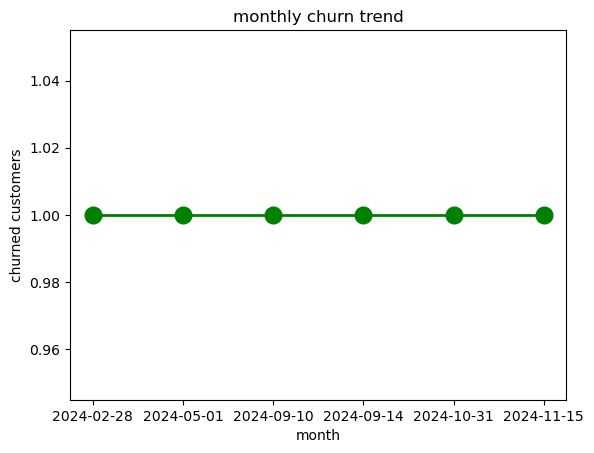

In [45]:
#4.1 monthly churn rate (time series KPI)
import pandas as pd

df_visual['cancellation_month'] = pd.to_datetime(df_visual['cancellation_date'])
df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
import matplotlib.pyplot as plt
plt.plot(churn_trend.index.astype(str), churn_trend.values, color = 'green', marker = 'o', linewidth = 2, markersize=12)

plt.title('monthly churn trend')
plt.xlabel('month')
plt.ylabel('churned customers')
plt.show()

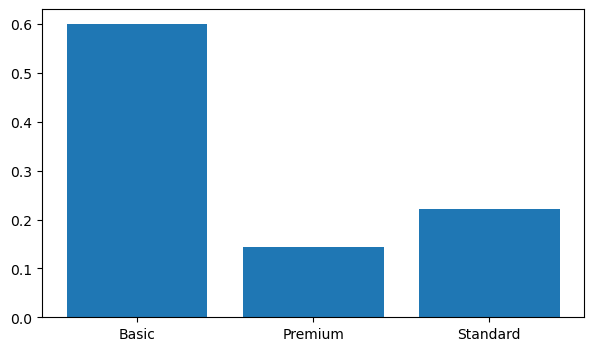

In [51]:
#4.2 churn by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
#colors = ['yellow', 'blue', 'red']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize = (7,4))
plt.bar(churn_plan.index, churn_plan.values)
plt.show()

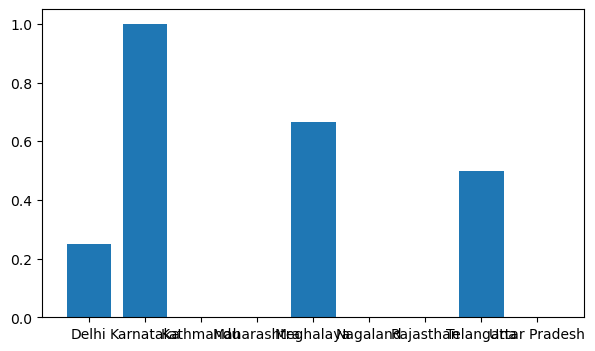

In [52]:
# 4.3 churn by states
churn_plan = df_visual.groupby('state')['churn_flag'].mean()
#colors = ['yellow', 'blue', 'red']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize = (7,4))
plt.bar(churn_plan.index, churn_plan.values)
plt.show()

In [ ]:
# visualisation using seaborn 
# heatmap

In [53]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk'],
      dtype='object')

In [54]:
df_visual[[ 'plan_type','contract_type','churn_score','churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,hugh,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,hugh,0


In [56]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,0
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,0


In [59]:
import warnings
warnings.filterwarnings("ignore")

In [60]:
df_encoded = df_visual[[ 'plan_type','contract_type','churn_score','churn_flag', 'churn_risk', 'escalations']]
categorial_cols = ['plan_type','contract_type','churn_risk']


for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

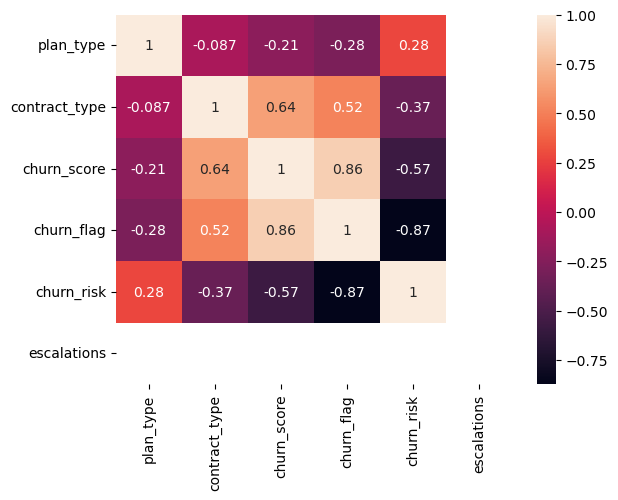

In [62]:
# heatmap
import seaborn as sns
sns.heatmap(df_encoded.corr(), annot = True)

In [66]:
import pandas as pd

df_encoded = df_visual[
    ['plan_type', 'contract_type', 'churn_score',
     'churn_flag', 'churn_risk', 'escalations']
].copy()

order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    ).codes

In [67]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,-1,0
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,-1,0


<Axes: >

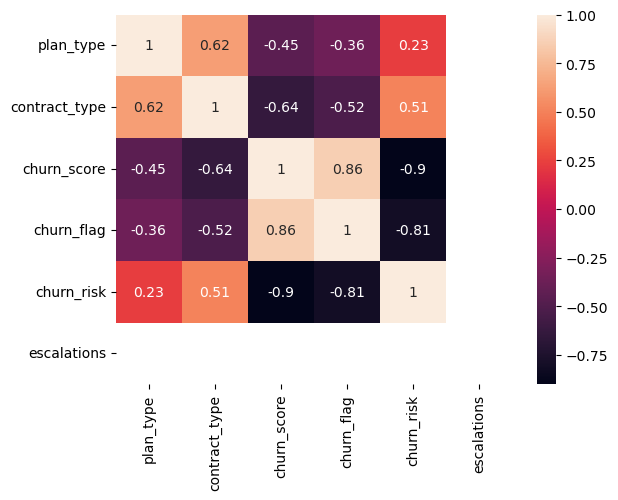

In [68]:
import seaborn as sns
sns.heatmap(df_encoded.corr(), annot = True)

In [65]:
df_visual['plan_type'].unique()

array(['Standard', 'Premium', 'Basic'], dtype=object)

In [69]:
import matplotlib.pyplot as plt

corr_matrix = df_encoded.corr(numeric_only=True)

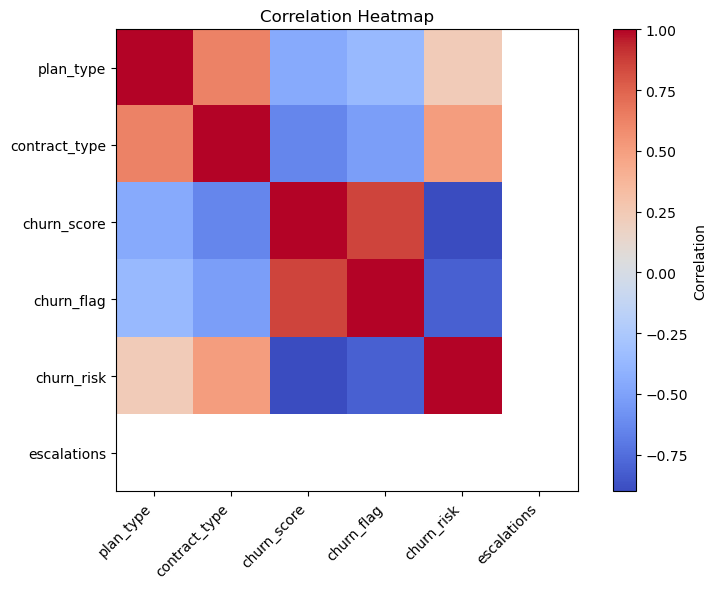

In [70]:
plt.figure(figsize=(8, 6))

plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

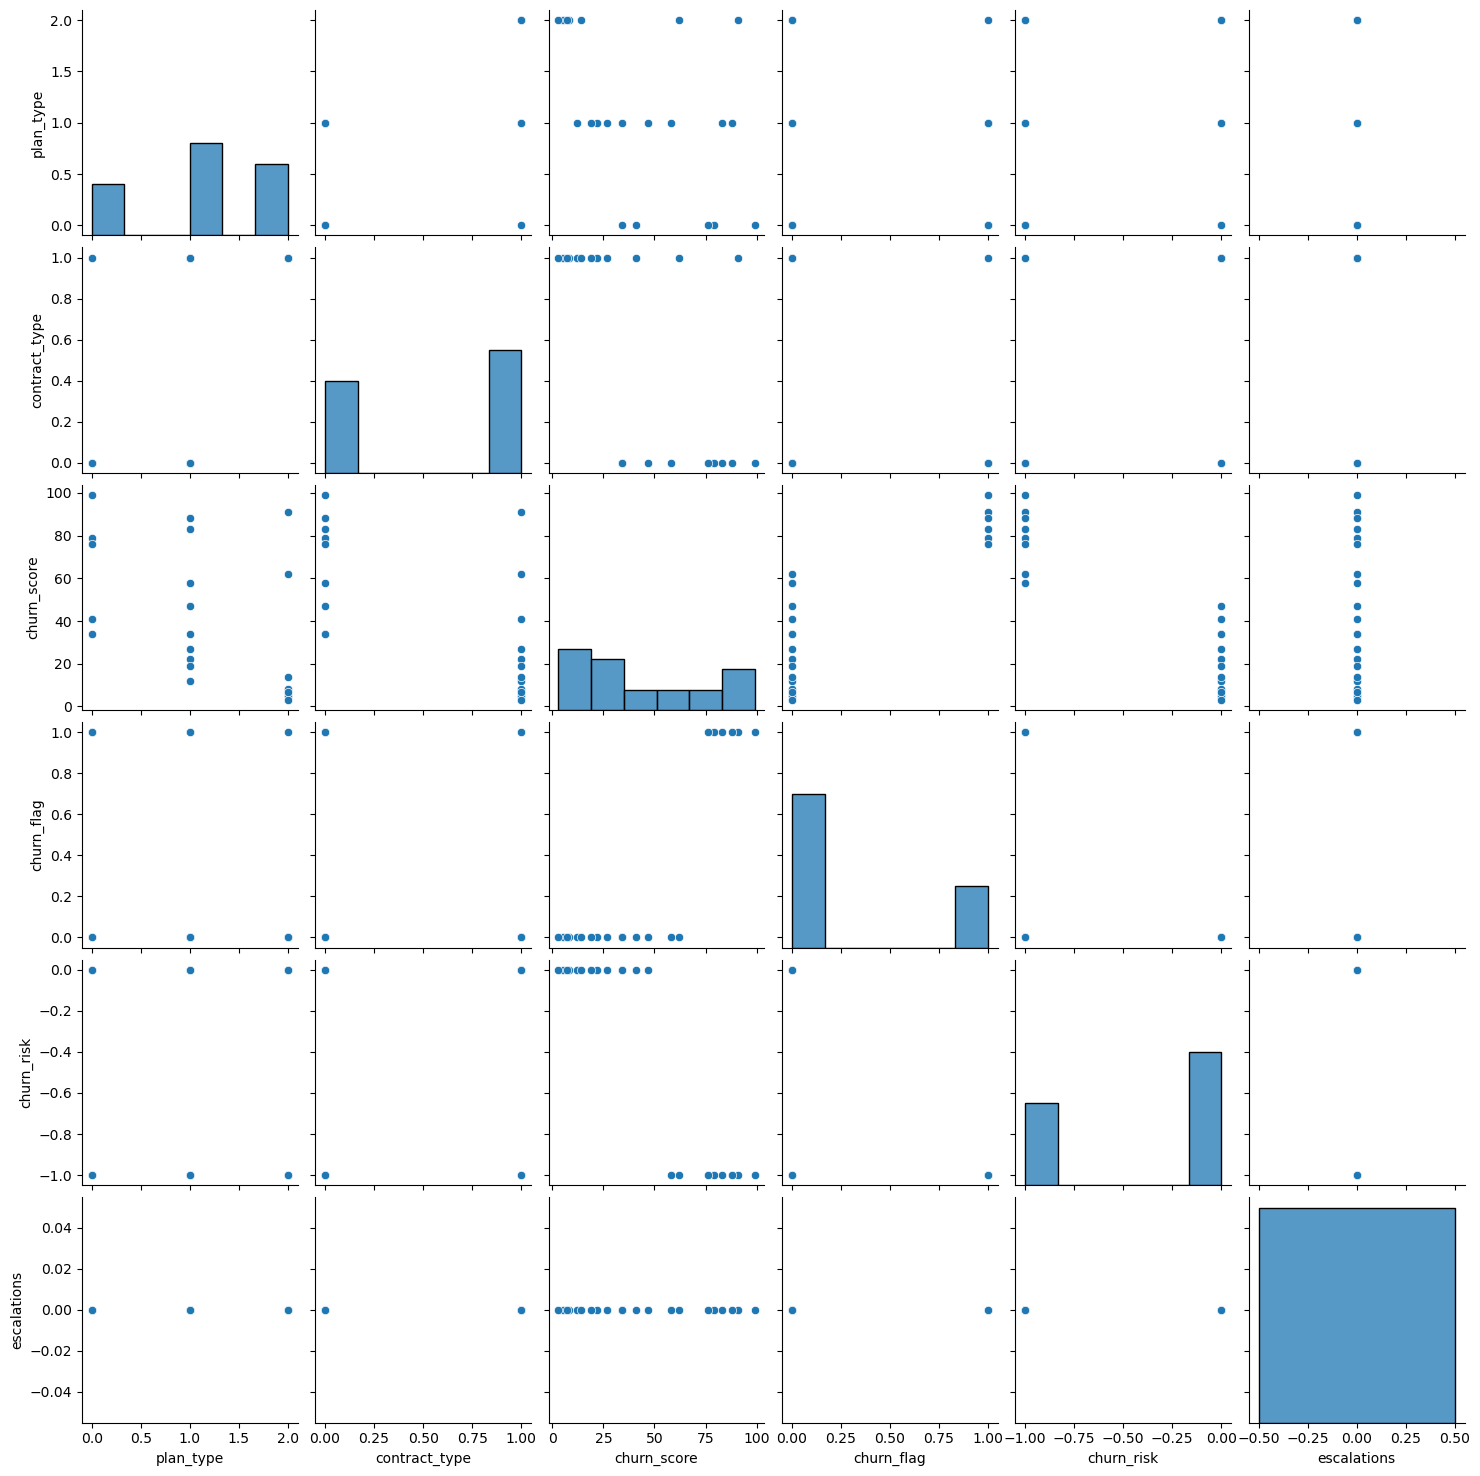

In [71]:
#pairplot
sns.pairplot(df_encoded)

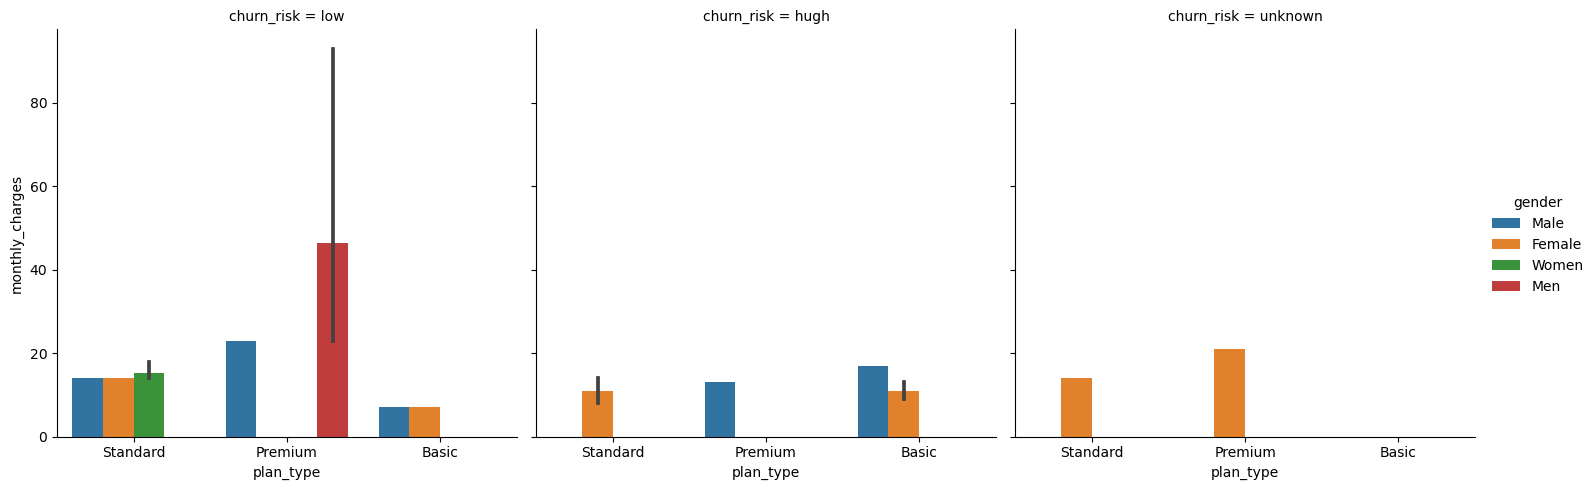

In [74]:
#catplt


import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk',
    kind='bar'   # or 'box', 'violin', 'strip', etc.
)

plt.show()

In [75]:
# pivot tables

pd.pivot_table(
        df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'




)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [77]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['churn_flag', 'monthly_charges', 'customerid'],
    aggfunc={
        'churn_flag': 'mean',
        'monthly_charges': 'sum',
        'customerid': 'nunique'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [ ]:
# working with sql in python


In [81]:
import sqlite3 
conn = sqlite3.connect('test_database.sqlite')


#table details
conn.execute("CREATE TABLE users(first_name TEXT, last_name TEXT, country TEXT, budget INTEGER)")
conn.commit()


OperationalError: table users already exists

In [6]:
import sqlite3 
conn = sqlite3.connect('test_database.sqlite')


#table details
conn.execute("CREATE TABLE users(first_name TEXT, last_name TEXT, country TEXT, budget INTEGER)")
conn.commit()


OperationalError: table users already exists

In [5]:
import sqlite3 
conn = sqlite3.connect('test_database.sqlite')


#table details
conn.execute("CREATE TABLE users(first_name TEXT, last_name TEXT, country TEXT, budget INTEGER)")
conn.commit()


OperationalError: table users already exists

In [8]:
import sqlite3
conn = sqlite3.connect("users.db")
cursor = conn.cursor()
cursor.execute
"""
INSERT INTO users VALUES
('madhu', 'gao', 'india', 5000)
('ash', 'rao', 'india', 6000)
('arna', 'yelli', 'india', 77000)
"""
conn.close()


In [12]:
# check inserted data
import pandas as pd
conn = sqlite3.connect('test_database.sqlite')
query = """ SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

In [13]:
df_results.head()

,first_name,last_name,country,budget


In [28]:
import sqlite3
conn = sqlite3.connect("test_database.sqlite")
conn = sqlite3.connect(" users.db")

query = "SELECT * FROM users "
query = "SELECT * FROM users "
cursor = conn.cursor()
cursor.execute
"""
INSERT INTO users VALUES
('madhu', 'gao', 'india', 5000)
('ash', 'rao', 'india', 6000)
('arna', 'yelli', 'india', 77000)
"""
conn.close()

print("data entered")

data entered


In [30]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("test_database.sqlite")

query = "SELECT * FROM users "
df_results = pd.read_sql_query(query, conn)

print(df_results)

Empty DataFrame
Columns: [first_name, last_name, country, budget]
Index: []


In [33]:
conn.close()